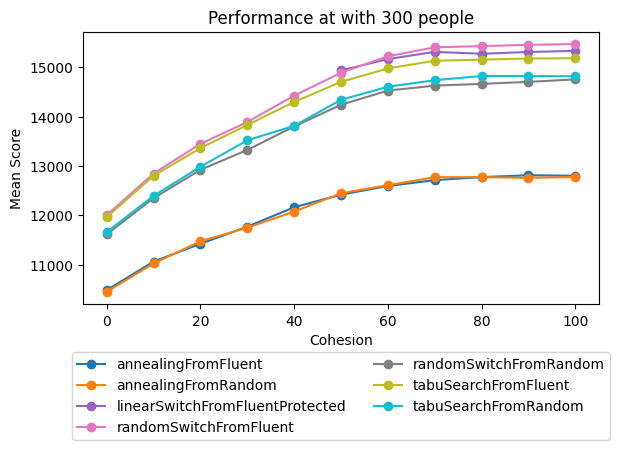

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

people = 300
algorithm_colors = {
    "annealingFromGrouped": "tab:blue",
    "annealingFromRandom": "tab:orange",
    "bruteForce": "tab:green",
    "linearSwitchFromGrouped": "tab:red",
    "linearSwitchFromGroupedProtected": "tab:purple",
    "linearSwitchFromRandom": "tab:brown",
    "randomSwitchFromGrouped": "tab:pink",
    "randomSwitchFromRandom": "tab:gray",
    "tabuSearchFromGrouped": "tab:olive",
    "tabuSearchFromRandom": "tab:cyan",
}

df = pd.read_csv('flattened_composite_experiments_data.csv')

# Convert score and time to numeric types, coercing invalid values to NaN
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['time'] = pd.to_numeric(df['time'], errors='coerce')

# Remove rows with NaN values
df = df.dropna()

# print(df)

summary = df.groupby(["algorithm", "n_people", "cohesion"]).agg(
    mean_score=("score", "mean"),
    std_score=("score", "std"),
    mean_time=("time", "mean"),
    std_time=("time", "std"),
).reset_index()

summary_c0 = summary[summary["n_people"] == people]

# print(summary)

pivot_data = summary_c0.pivot(
    index="cohesion",
    columns="algorithm",
    values="mean_score"
)

# Filter colors to only include algorithms in the pivot table
colors = {algo: algorithm_colors.get(algo, "tab:gray") for algo in pivot_data.columns}

pivot_data.plot(
    title=f"Performance at with {people} people",
    xlabel="Cohesion",
    ylabel="Mean Score",
    marker="o",
    color=colors
)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.savefig(f'plots/{people}p_score_cohesion_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# print("Plot saved as 'performance_plot.png'")
# print(f"Plot shows performance comparison of {len(summary_c0['algorithm'].unique())} algorithms with 100 people across {len(summary_c0['cohesion'].unique())} cohesion levels")


In [2]:
import pandas as pd

# Load data
df = pd.read_csv("flattened_composite_experiments_data.csv")

# Mark DNFs before conversion
df["is_dnf"] = df["score"] == "DNF"

# Convert to numeric (DNF -> NaN)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["time"] = pd.to_numeric(df["time"], errors="coerce")

# Group and compute everything
result = df.groupby("algorithm").agg(
    avg_score=("score", "mean"),
    avg_time=("time", "mean"),
    total_runs=("score", "size"),
    dnf_count=("is_dnf", "sum")
)

# Compute percentage
result["dnf_percentage"] = (result["dnf_count"] / result["total_runs"]) * 100

# Optional: valid runs
result["valid_runs"] = result["total_runs"] - result["dnf_count"]

# Sort (optional)
result = result.sort_values(by="avg_score", ascending=False)

# Round for readability
result = result.round({
    "avg_score": 2,
    "avg_time": 4,
    "dnf_percentage": 2
})

print(result)

                                 avg_score  avg_time  total_runs  dnf_count  \
algorithm                                                                     
tabuSearchFromGrouped               5339.04   10.4445        4400          4   
linearSwitchFromGrouped             5294.38   13.7938        4400          4   
randomSwitchFromGrouped             5179.31    2.6120        4400          4   
linearSwitchFromGroupedProtected    5175.69    8.9223        4400          4   
linearSwitchFromRandom             5064.94   14.7697        4400          0   
annealingFromGrouped                4837.22    2.0187        4400          4   
randomSwitchFromRandom             4813.69    2.8582        4400          0   
tabuSearchFromRandom               4721.85   11.1239        4400          0   
annealingFromRandom                4413.55    2.3459        4400          0   
bruteForce                         2095.07   23.2539        2000          0   

                                 dnf_percentag

In [ ]:
def analyze_for_n(df, n_people):
    df_n = df[df["n_people"] == n_people].copy()

    df_n["is_dnf"] = df_n["score"] == "DNF"
    df_n["score"] = pd.to_numeric(df_n["score"], errors="coerce")
    df_n["time"] = pd.to_numeric(df_n["time"], errors="coerce")

    result = df_n.groupby("algorithm").agg(
        avg_score=("score", "mean"),
        avg_time=("time", "mean"),
        total_runs=("score", "size"),
        dnf_count=("is_dnf", "sum")
    )

    result["dnf_percentage"] = (result["dnf_count"] / result["total_runs"]) * 100
    result["valid_runs"] = result["total_runs"] - result["dnf_count"]

    return result.sort_values(by="avg_score", ascending=False).round(2)

In [ ]:
import pandas as pd
import numpy as np

# Load the fullrun data
df = pd.read_csv('flattened_fullrun_data.csv')

# Convert score to numeric, handling any DNF or error values
df['score'] = pd.to_numeric(df['score'], errors='coerce')

# Remove rows with NaN scores
df = df.dropna(subset=['score'])

# Define algorithm mappings
algo_types = {
    'linearSwitch': ['linearSwitchFromRandom', 'linearSwitchFromGrouped'],
    'randomSwitch': ['randomSwitchFromRandom', 'randomSwitchFromGrouped'],
    'annealing': ['annealingFromRandom', 'annealingFromGrouped'],
    'tabuSearch': ['tabuSearchFromRandom', 'tabuSearchFromGrouped']
}

results = []

# For each algorithm type
for algo_name, variants in algo_types.items():
    random_variant = variants[0]
    grouped_variant = variants[1]

    # Get data for each variant
    df_random = df[df['algorithm'] == random_variant]
    df_grouped = df[df['algorithm'] == grouped_variant]

    if len(df_random) == 0 or len(df_grouped) == 0:
        print(f"Warning: No data for {algo_name}")
        continue

    # Calculate averages
    random_avg = df_random['score'].mean()
    grouped_avg = df_grouped['score'].mean()

    # Score difference (higher is better, so Grouped - Random, positive is good)
    score_diff = grouped_avg - random_avg

    # Relative improvement in percent: (Grouped - Random) / Random * 100
    relative_improvement = ((grouped_avg - random_avg) / random_avg * 100) if random_avg != 0 else 0

    # Count wins: for each unique dataset (n_people, cohesion), see if grouped avg > random avg
    # Group by n_people and cohesion to get averages per dataset
    df_random_by_dataset = df_random.groupby(['n_people', 'cohesion'])['score'].mean()
    df_grouped_by_dataset = df_grouped.groupby(['n_people', 'cohesion'])['score'].mean()

    # Find common datasets
    common_datasets = df_random_by_dataset.index.intersection(df_grouped_by_dataset.index)

    if len(common_datasets) > 0:
        wins = sum(df_grouped_by_dataset[common_datasets] > df_random_by_dataset[common_datasets])
        ties = sum(df_grouped_by_dataset[common_datasets] == df_random_by_dataset[common_datasets])
        grouped_wins_percent = (wins / len(common_datasets)) * 100
        ties_percent = (ties / len(common_datasets)) * 100
    else:
        grouped_wins_percent = 0
        ties_percent = 0

    results.append({
        'Algorithm': algo_name,
        'Random Avg': random_avg,
        'Grouped Avg': grouped_avg,
        'Score Difference': score_diff,
        'Relative Improvement (%)': relative_improvement,
        'Grouped Wins (%)': grouped_wins_percent,
        'Ties (%)': ties_percent
    })

# Create dataframe from results
results_df = pd.DataFrame(results)

# Calculate totals/averages
total_row = {
    'Algorithm': 'Total/Average',
    'Random Avg': results_df['Random Avg'].mean(),
    'Grouped Avg': results_df['Grouped Avg'].mean(),
    'Score Difference': results_df['Score Difference'].mean(),
    'Relative Improvement (%)': results_df['Relative Improvement (%)'].mean(),
    'Grouped Wins (%)': results_df['Grouped Wins (%)'].mean(),
    'Ties (%)': results_df['Ties (%)'].mean()
}

results_df = pd.concat([results_df, pd.DataFrame([total_row])], ignore_index=True)

# Format for nice display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("\n" + "="*120)
print("FULLRUN DATA COMPARISON: Random vs Grouped Algorithms")
print("="*120)
print(results_df.to_string(index=False))
print("="*120)

# Save to CSV
results_df.to_csv('fullrun_comparison_table.csv', index=False)
print("\nTable saved to: fullrun_comparison_table.csv")


In [ ]:
import pandas as pd
import numpy as np

# Function to analyze fullrun data for a specific number of people
def analyze_fullrun_for_n_people(n_people_filter=None):
    # Load the fullrun data
    df = pd.read_csv('flattened_fullrun_data.csv')

    # Convert score to numeric, handling any DNF or error values
    df['score'] = pd.to_numeric(df['score'], errors='coerce')

    # Remove rows with NaN scores
    df = df.dropna(subset=['score'])

    # Filter by number of people if specified
    if n_people_filter is not None:
        df = df[df['n_people'] == n_people_filter]
        if len(df) == 0:
            print(f"No data found for {n_people_filter} people")
            return

    # Define algorithm mappings
    algo_types = {
        'linearSwitch': ['linearSwitchFromRandom', 'linearSwitchFromGrouped'],
        'randomSwitch': ['randomSwitchFromRandom', 'randomSwitchFromGrouped'],
        'annealing': ['annealingFromRandom', 'annealingFromGrouped'],
        'tabuSearch': ['tabuSearchFromRandom', 'tabuSearchFromGrouped']
    }

    results = []

    # For each algorithm type
    for algo_name, variants in algo_types.items():
        random_variant = variants[0]
        grouped_variant = variants[1]

        # Get data for each variant
        df_random = df[df['algorithm'] == random_variant]
        df_grouped = df[df['algorithm'] == grouped_variant]

        if len(df_random) == 0 or len(df_grouped) == 0:
            print(f"Warning: No data for {algo_name}")
            continue

        # Calculate averages
        random_avg = df_random['score'].mean()
        grouped_avg = df_grouped['score'].mean()

        # Score difference (higher is better, so Grouped - Random, positive is good)
        score_diff = grouped_avg - random_avg

        # Relative improvement in percent: (Grouped - Random) / Random * 100
        relative_improvement = ((grouped_avg - random_avg) / random_avg * 100) if random_avg != 0 else 0

        # Count wins: for each unique dataset (n_people, cohesion), see if grouped avg > random avg
        # Group by n_people and cohesion to get averages per dataset
        df_random_by_dataset = df_random.groupby(['n_people', 'cohesion'])['score'].mean()
        df_grouped_by_dataset = df_grouped.groupby(['n_people', 'cohesion'])['score'].mean()

        # Find common datasets
        common_datasets = df_random_by_dataset.index.intersection(df_grouped_by_dataset.index)

        if len(common_datasets) > 0:
            wins = sum(df_grouped_by_dataset[common_datasets] > df_random_by_dataset[common_datasets])
            ties = sum(df_grouped_by_dataset[common_datasets] == df_random_by_dataset[common_datasets])
            grouped_wins_percent = (wins / len(common_datasets)) * 100
            ties_percent = (ties / len(common_datasets)) * 100
        else:
            grouped_wins_percent = 0
            ties_percent = 0

        results.append({
            'Algorithm': algo_name,
            'Random Avg': random_avg,
            'Grouped Avg': grouped_avg,
            'Score Difference': score_diff,
            'Relative Improvement (%)': relative_improvement,
            'Grouped Wins (%)': grouped_wins_percent,
            'Ties (%)': ties_percent
        })

    # Create dataframe from results
    results_df = pd.DataFrame(results)

    # Calculate totals/averages
    total_row = {
        'Algorithm': 'Total/Average',
        'Random Avg': results_df['Random Avg'].mean(),
        'Grouped Avg': results_df['Grouped Avg'].mean(),
        'Score Difference': results_df['Score Difference'].mean(),
        'Relative Improvement (%)': results_df['Relative Improvement (%)'].mean(),
        'Grouped Wins (%)': results_df['Grouped Wins (%)'].mean(),
        'Ties (%)': results_df['Ties (%)'].mean()
    }

    results_df = pd.concat([results_df, pd.DataFrame([total_row])], ignore_index=True)

    # Format for nice display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)

    filter_text = f" (filtered to {n_people_filter} people)" if n_people_filter is not None else " (all data)"

    print("\n" + "="*140)
    print(f"FULLRUN DATA COMPARISON: Random vs Grouped Algorithms{filter_text}")
    print("="*140)
    print(results_df.to_string(index=False))
    print("="*140)

    # Save to CSV
    filename = f'fullrun_comparison_table_{n_people_filter}p.csv' if n_people_filter is not None else 'fullrun_comparison_table_all.csv'
    results_df.to_csv(filename, index=False)
    print(f"\nTable saved to: {filename}")

    return results_df

# Example usage - analyze for all data
print("=== ANALYSIS FOR ALL DATA ===")
analyze_fullrun_for_n_people()

# Example usage - analyze for specific number of people
print("\n=== ANALYSIS FOR 8 PEOPLE ===")
analyze_fullrun_for_n_people(8)

# Example usage - analyze for specific number of people
print("\n=== ANALYSIS FOR 30 PEOPLE ===")
analyze_fullrun_for_n_people(30)

# Example usage - analyze for specific number of people
print("\n=== ANALYSIS FOR 100 PEOPLE ===")
analyze_fullrun_for_n_people(100)

print("\n=== ANALYSIS FOR 300 PEOPLE ===")
analyze_fullrun_for_n_people(300)


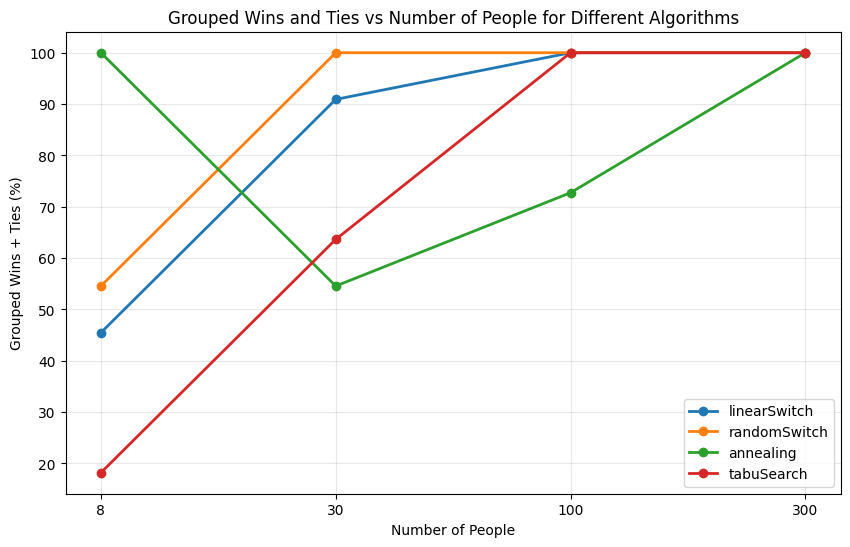

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# List of CSV files and corresponding number of people
files = [
    'fullrun_comparison_table_8p.csv',
    'fullrun_comparison_table_30p.csv',
    'fullrun_comparison_table_100p.csv',
    'fullrun_comparison_table_300p.csv'
]
people_counts = [8, 30, 100, 300]

# Algorithms to plot
algorithms = ['linearSwitch', 'randomSwitch', 'annealing', 'tabuSearch']

# Dictionary to hold data for each algorithm: list of (wins_percent, people)
data_wins = {algo: [] for algo in algorithms}

# Load data from each file
for file, people in zip(files, people_counts):
    df = pd.read_csv(file)
    for algo in algorithms:
        row = df[df['Algorithm'] == algo]
        if not row.empty:
            wins_percent = row['Grouped Wins (%)'].values[0]
            data_wins[algo].append((wins_percent, people))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

x_positions = range(len(people_counts))

for algo in algorithms:
    if data_wins[algo]:
        points = sorted(data_wins[algo], key=lambda x: x[1])
        y_vals = [pt[0] for pt in points]

        ax.plot(
            x_positions,
            y_vals,
            marker='o',
            label=algo,
            linewidth=2
        )

ax.set_xlabel('Number of People')
ax.set_ylabel('Grouped Wins (%)')
ax.set_title('Grouped Wins vs Number of People for Different Algorithms')

# Evenly spaced labels
ax.set_xticks(list(x_positions))
ax.set_xticklabels(people_counts)

ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.savefig('plots/grouped_wins_vs_people.png', dpi=300, bbox_inches='tight')
plt.show()

